In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import torch

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# Suppress torch._dynamo compilation errors and fall back to eager mode
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

from pathlib import Path
import os
import pickle
import math
import string
from collections import OrderedDict
sys.path.append(str(Path.cwd().parent))
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [25]:
def plot_multiple_regression_series(data_dicts, titles=None, save_path=None, verbose=False):
    """
    data_dicts: list of data_dict, where each data_dict has the structure {label: (true_vals, pred_vals)}
    titles: list of str, corresponding to the subplot titles for each data_dict
    """
    n = len(data_dicts)
    cols = 2 if n > 1 else 1
    rows = math.ceil(n / cols)   
    
    fig, axs = plt.subplots(rows, cols, figsize=(8*cols, 5*rows), squeeze=False)
    axs = axs.ravel()

    all_handles, all_labels = [], []  

    for i, data_dict in enumerate(data_dicts):
        ax = axs[i]
        idx_start = 0
        for label, (true_vals, pred_vals) in data_dict.items():
            n_pts = len(true_vals)
            idx_range = np.arange(idx_start, idx_start + n_pts)

            h1, = ax.plot(idx_range, true_vals, label=f'{label} - True')
            h2, = ax.plot(idx_range, pred_vals, linestyle='--', label=f'{label} - Predicted')

            idx_start += n_pts

            all_handles.extend([h1, h2])
            all_labels.extend([h1.get_label(), h2.get_label()])

        ax.set_xlabel("Sample Index", fontsize=10)
        ax.set_ylabel("Magnitude", fontsize=10)
        if titles is not None and i < len(titles):
            ax.set_title(titles[i], fontsize=12)
        ax.grid(True)

        label = f"({string.ascii_lowercase[i]})"
        ax.text(
            0.98, 0.05, label,
            transform=ax.transAxes, 
            ha="right", va="bottom",
            fontsize=12, fontweight="medium"  
        )

    uniq = dict(zip(all_labels, all_handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=3, fontsize=10)

    plt.tight_layout(rect=[0,0.05,1,1])  
    if save_path:
        plt.savefig(save_path, dpi=300)
        if verbose:
            print(f"[✔] Saved series plots to {save_path}")
    plt.show()


In [24]:
def plot_multiple_regression_series_v2(
    data_dicts,
    titles=None,
    save_path=None,
    verbose=False,
    cols=2,
    figsize_per_col=6.4,
    figsize_per_row=3.8,
    linewidth=1.8,
    pred_linestyle="--",
    true_color="k",          # True: black
    pred_color="tab:orange", # Pred: orange
    split_order=("train", "val", "test"),
    split_facecolors=None,   # background colors for splits
    alpha_span=0.10,
    unify_ylim=True,
    ylim_pad=0.15,
    fontsize=10,
    title_fontsize=11,
    panel_label_fontsize=11,
    ncol_legend=4,
    show=True,
):
    """
    Paper-friendly multi-panel regression plot.

    Expected input:
      data_dicts: list of dicts, each dict: {label: (true_vals, pred_vals)}
                 Labels can be "train"/"val"/"test" (recommended). Others treated as segments too.
      titles: list of subplot titles

    Improvements vs original:
      - Plot only ONE True and ONE Pred line per subplot (concatenated across segments).
      - Use background spans to indicate train/val/test segments.
      - One global legend (clean and readable after shrinking).
      - Consistent colors, line widths, fonts, and optional unified y-limits.
    """

    if split_facecolors is None:
        split_facecolors = {
            "train": "tab:green",
            "val":   "tab:blue",
            "test":  "tab:purple",
        }

    n = len(data_dicts)
    cols = min(cols, n) if n > 0 else 1
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(
        rows, cols,
        figsize=(figsize_per_col * cols, figsize_per_row * rows),
        squeeze=False
    )
    axs = axs.ravel()

    # ---- precompute global y-limits (optional) ----
    global_min, global_max = np.inf, -np.inf
    if unify_ylim:
        for data_dict in data_dicts:
            for _, (true_vals, pred_vals) in data_dict.items():
                if len(true_vals) > 0:
                    global_min = min(global_min, np.min(true_vals), np.min(pred_vals))
                    global_max = max(global_max, np.max(true_vals), np.max(pred_vals))
        if np.isfinite(global_min) and np.isfinite(global_max):
            global_min -= ylim_pad
            global_max += ylim_pad
        else:
            unify_ylim = False

    # ---- helper: order segments (train/val/test first if present) ----
    def ordered_items(d):
        keys = list(d.keys())
        ordered = []
        for k in split_order:
            if k in d:
                ordered.append((k, d[k]))
        # append remaining keys in original order
        for k in keys:
            if k not in split_order:
                ordered.append((k, d[k]))
        return ordered

    for i, data_dict in enumerate(data_dicts):
        ax = axs[i]

        # Build concatenated series
        idx_start = 0
        t_all, p_all = [], []
        spans = []  # (start, end, label)

        for label, (true_vals, pred_vals) in ordered_items(data_dict):
            true_vals = np.asarray(true_vals)
            pred_vals = np.asarray(pred_vals)
            n_pts = len(true_vals)
            if n_pts == 0:
                continue
            idx_range = np.arange(idx_start, idx_start + n_pts)

            t_all.append((idx_range, true_vals))
            p_all.append((idx_range, pred_vals))
            spans.append((idx_start, idx_start + n_pts, label))

            idx_start += n_pts

        # Background spans for splits
        for (s, e, lab) in spans:
            if lab in split_facecolors:
                ax.axvspan(s, e, color=split_facecolors[lab], alpha=alpha_span, lw=0)

        # Plot lines (concatenate segments, but keep continuous x)
        for (xseg, yseg) in t_all:
            ax.plot(xseg, yseg, color=true_color, lw=linewidth)
        for (xseg, yseg) in p_all:
            ax.plot(xseg, yseg, color=pred_color, lw=linewidth, ls=pred_linestyle)

        # Labels, title, grid
        ax.set_xlabel("Sample index", fontsize=fontsize)
        ax.set_ylabel("Magnitude", fontsize=fontsize)
        if titles is not None and i < len(titles):
            ax.set_title(titles[i], fontsize=title_fontsize)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

        if unify_ylim:
            ax.set_ylim(global_min, global_max)

        # Panel label (a)(b)...
        panel = f"({string.ascii_lowercase[i]})"
        ax.text(
            0.98, 0.06, panel,
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=panel_label_fontsize,
            fontweight="medium"
        )

    # Turn off unused axes
    for j in range(n, len(axs)):
        axs[j].axis("off")

    # ---- Global legend ----
    legend_items = [
        Line2D([0], [0], color=true_color, lw=linewidth, label="True"),
        Line2D([0], [0], color=pred_color, lw=linewidth, ls=pred_linestyle, label="Predicted"),
    ]
    # add split patches only if present
    present_splits = set()
    for d in data_dicts:
        present_splits |= set(d.keys())
    for k in split_order:
        if k in present_splits and k in split_facecolors:
            legend_items.append(Patch(facecolor=split_facecolors[k], alpha=alpha_span, label=k))

    fig.legend(
        handles=legend_items,
        loc="lower center",
        ncol=min(ncol_legend, len(legend_items)),
        fontsize=fontsize,
        frameon=True
    )

    # Layout: leave room for bottom legend
    fig.tight_layout(rect=[0, 0.08, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        if verbose:
            print(f"[✔] Saved series plots to {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


In [12]:
from  src.train.config_setup import load_and_prepare_model
from src.data.preparation import prepare_data, prepare_data_lstm  
from src.train.regressor_train_step import  get_data_dict
def get_data_dict_from_checkpoint(checkpoint_path_list, device, prepare_data_func, shared_data=None):
    """
    Given a list of checkpoint paths, load each model and prepare the data dictionary.
    If `shared_data` is provided, reuse it to avoid preparing the same dataset multiple times.
    Returns: (data_dict_list, shared_data) so callers can pass `shared_data` to subsequent calls.
    """
    data_dict_list = []
    for checkpoint_path in checkpoint_path_list:
        model, args = load_and_prepare_model(checkpoint_path=checkpoint_path, device=device, compile=False)
       
        if shared_data is None:
            df, train_loader, val_loader, test_loader, catalog_ds = prepare_data_func(
                base_dir=f"../data/{args.dataset}", args=args
            )
            shared_data = (train_loader, val_loader, test_loader)
        train_loader, val_loader, test_loader = shared_data
        data_dict = get_data_dict([train_loader, val_loader, test_loader], model, device)
        data_dict_list.append(data_dict)
        del model
        torch.cuda.empty_cache()

    return data_dict_list, shared_data

In [13]:
checkpoint_path_lstm = [
     Path("../checkpoints/lstm_20250906-152053/last_model_1.pth"),
    
]
checkpoint_path_reg1 = [
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-180531/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-195612/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-201607/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-194201/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-192629/last_model_1.pth")
]
checkpoint_path_reg2 = [
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-180531/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-195612/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-201607/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-194201/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-192629/last_model_1.pth")
    # checkpoints/reg_mixer_attnpl_t_20250921-182545
]
# Prepare data dicts and reuse shared_data to avoid multiple data preparations
lstm_data_dicts, _ = get_data_dict_from_checkpoint(checkpoint_path_lstm, device, prepare_data_lstm)
reg_data_dicts1, shared_data = get_data_dict_from_checkpoint(checkpoint_path_reg1, device, prepare_data)
reg_data_dicts2, shared_data = get_data_dict_from_checkpoint(checkpoint_path_reg2, device, prepare_data, shared_data=shared_data)
data_dicts = lstm_data_dicts + reg_data_dicts1 + reg_data_dicts2

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'lstm', 'task_type': 'regression', 'batch_size': 128, 'accumulation_steps': 1, 'warmup_ratio': 'None', 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': 0.6, 'scheduler_patience': 5, 'scheduler_threshold': 0.0001, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'lstm_hidden_size': 256, 'lstm_num_layers': 4, 'lstm_dropout': 0.3, 'epochs': 200, 'save_dir': 'checkpoints/lstm_20250906-152053', 'cuda_id': '0', 'dataset': 'ChuanDian', 'criterion_name': 'smooth_l1', 'criterion_cfg': {'beta': 0.5}, 'seed': 0, 'Mc': 3, 'Mf': 3, 'Mag_elaps': [6, 6.5, 7, 7.5], 'Twindow': 360, 'Tfore': 180, 'dt': 10, 'context_len': 0, 'dMag': 0.1, 'split_by_time': True, 'time_step': 5, 'feature_cols': ['Num', 'Mag_max', 'Mag_mean', 'b_lsq', 'a_lsq', 'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk', 'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk', 'beta'

[✔] Loading cached data from: ../data/ChuanDian/processed/rf_classifier/rf_Mag_elaps_[6, 6.5, 7, 7.5]_Mc_3_Mf_3_Tfore_180_Twindow_360_context_len_0_dMag_0.1_dt_10.pkl
   Original number of samples: 1818, number of samples after cleaning: 1818
   Replaced NaN values in X with 0.0
Train set: 1454 samples
Validation set: 181 samples
Test set: 183 samples
Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched

In [14]:
for x,y in shared_data[0]:
    print(x.device, y.shape)
    break

cpu torch.Size([64])


In [15]:
os.makedirs("figs_data", exist_ok=True)
with open("figs_data/reg_data_dicts.pkl", "wb") as f:
    pickle.dump(data_dicts, f)

In [16]:
with open("figs_data/reg_data_dicts.pkl", "rb") as f:  # "rb" 表示以二进制只读模式
    data_dicts = pickle.load(f)

In [17]:
data_dicts[0]['Train']

(array([5.9, 5.9, 5.9, ..., 5.4, 5.4, 5.4], dtype=float32),
 array([6.180707 , 6.2517104, 6.2878947, ..., 5.0528927, 5.0572877,
        5.057252 ], dtype=float32))

In [18]:
titles = [
    "LSTM",
    "EM-EQF",
    r"EM-EQF (+$\log(\Delta t)$)",
    "EM-EQF (-T-XPOS)",
    "EM-EQF (-TMAP)",
    "EM-EQF (-Pretrain)",
]

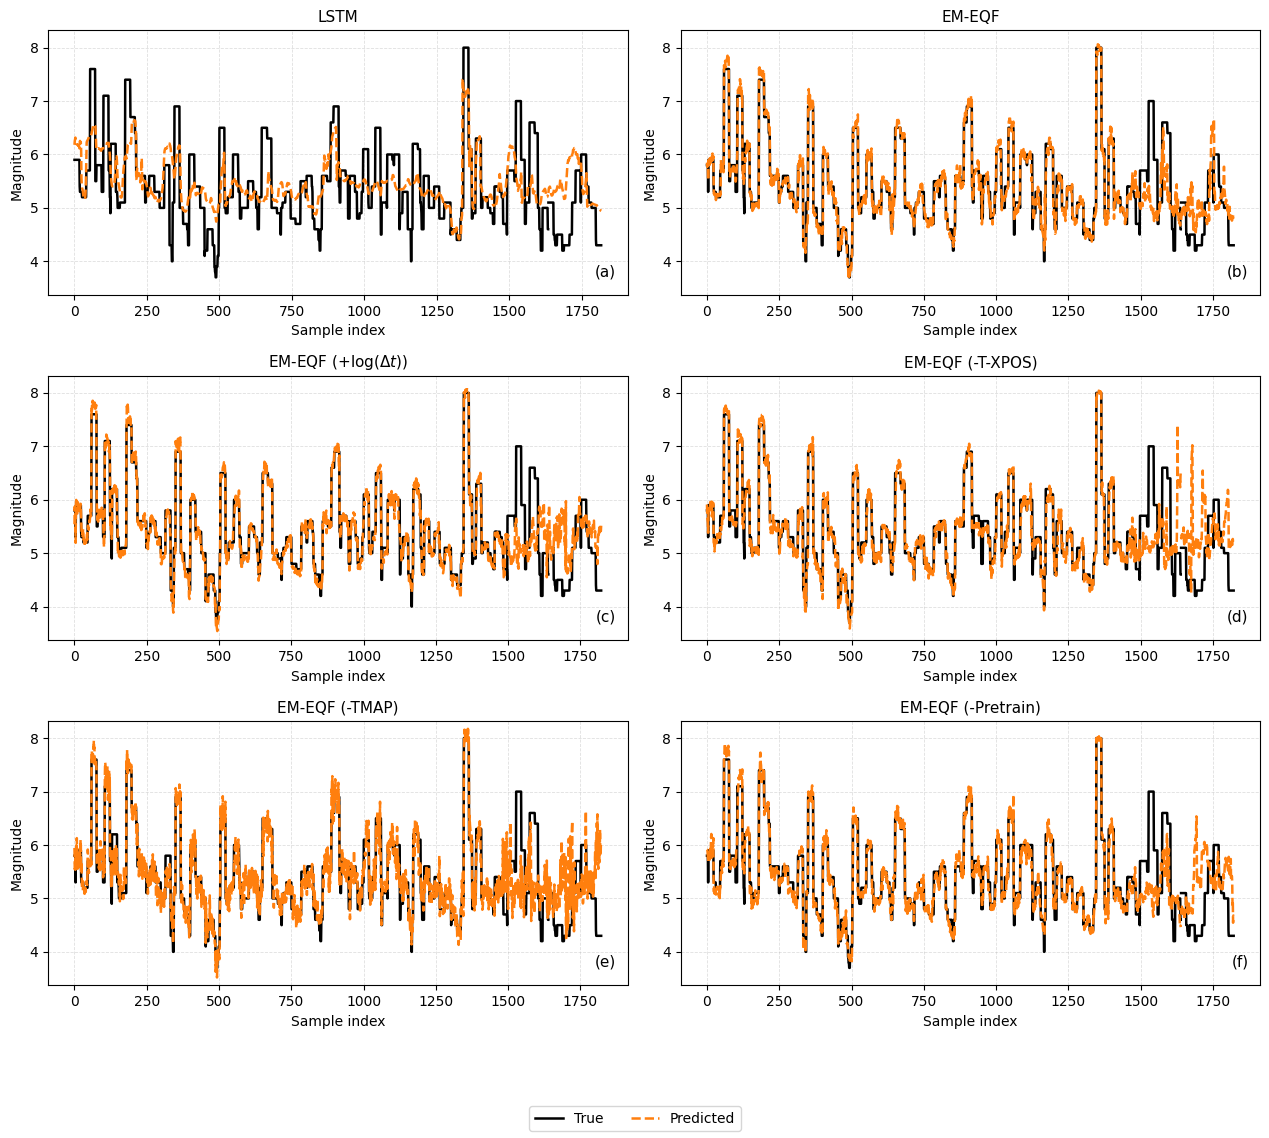

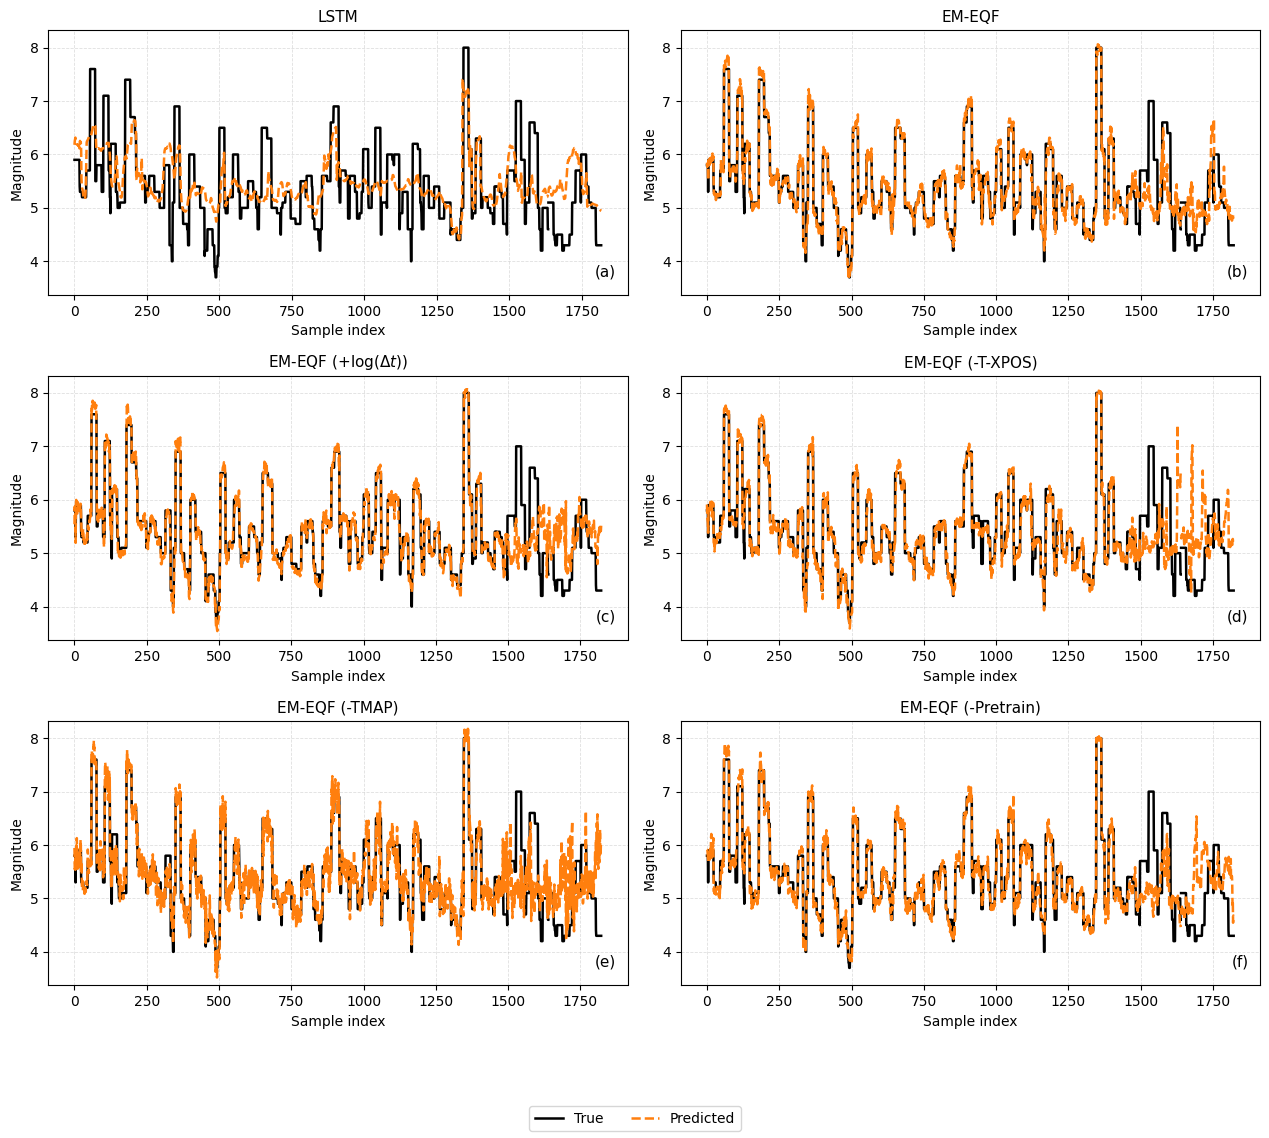

In [27]:
plot_multiple_regression_series_v2(data_dicts , titles=titles, save_path="figs/regression_plots.pdf", verbose=False)